# 🌿 Cost–Benefit Analysis of Increasing Canopy Cover

- This notebook models the **cost–benefit of agroforestry shading** for tropical perennial crops, focusing on **microclimate regulation** as an ecosystem service. 
- *Biodiversity Link*: Canopy cover, as a proxy for ecosystem condition, influences  the **hazard intensity** (e.g. cooling).


**🎯 Objective**  
- Quantify how increasing **canopy cover** reduces climate risk (via cooling) and improves **crop yield**, and compare this with the **cost of implementation**.


**📦 Model Components**
- **Hazard**: Mean annual **VPD**  
- **Exposure**: Spatially resolved average coffe production for Mexico.
- **Impact Function**: Yield loss curve  
- **Adaptation Measure**: Increase in **canopy cover**

**🔍 Uncertainty Parameters**  
- Crop production
- Vulnerability (Impact function)
- Cost of measure  


**🛠️ Notes & Future goals**  
- Complements a second notebook focused on **risk to the ecosystem service itself**  
- Future goal: couple both notebooks to assess how **ecosystem degradation leads to value chain risk**  
- Generic structure can potentially be extended to model other ES-related benefits, such as: Soil moisture retention, Erosion control, Pollination and pest regulation




## 1 - Initial parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type
hazard_type = 'VPD'

## 2 - Exposure

**🌾 Coffe Production and Plantation Area (2020)**

We use data from the 2020 MAPSPAM dataset to estimate **coffe production (in tonnes)** and **plantation area** at a 10 km × 10 km grid resolution.

**What we use:**
- **Production per grid cell** (in tonnes)
- **Planted area per cell** — used to estimate the cost of increasing canopy cover at each location.

**Data source:**  
- MAPSPAM raster data: [https://mapspam.info](https://mapspam.info) ( Readme and details: [Read Me file](https://www.dropbox.com/scl/fi/z468wh0d8abfohol991r5/Readme.txt?rlkey=el1w3zeykz909aadrx2xuck36&e=1&dl=0))

**Notes:**
- Grid cells with **zero production** are removed.  
- Since exact plantation locations are unavailable, we work with **grid-level estimates**.  
- For custom analysis, users can upload their own **site-specific exposure files** (points or polygons), including variables like **canopy cover** and **species composition**.


### Download the data

You need to download the `spam2020V2r0_global_harvested_area` and `spam2020V1r0_global_production` dataset manually from [https://mapspam.info](https://mapspam.info):


Place the ZIP and extract the file in your `INPUT_DIR` defined in the first cell of the notebook 

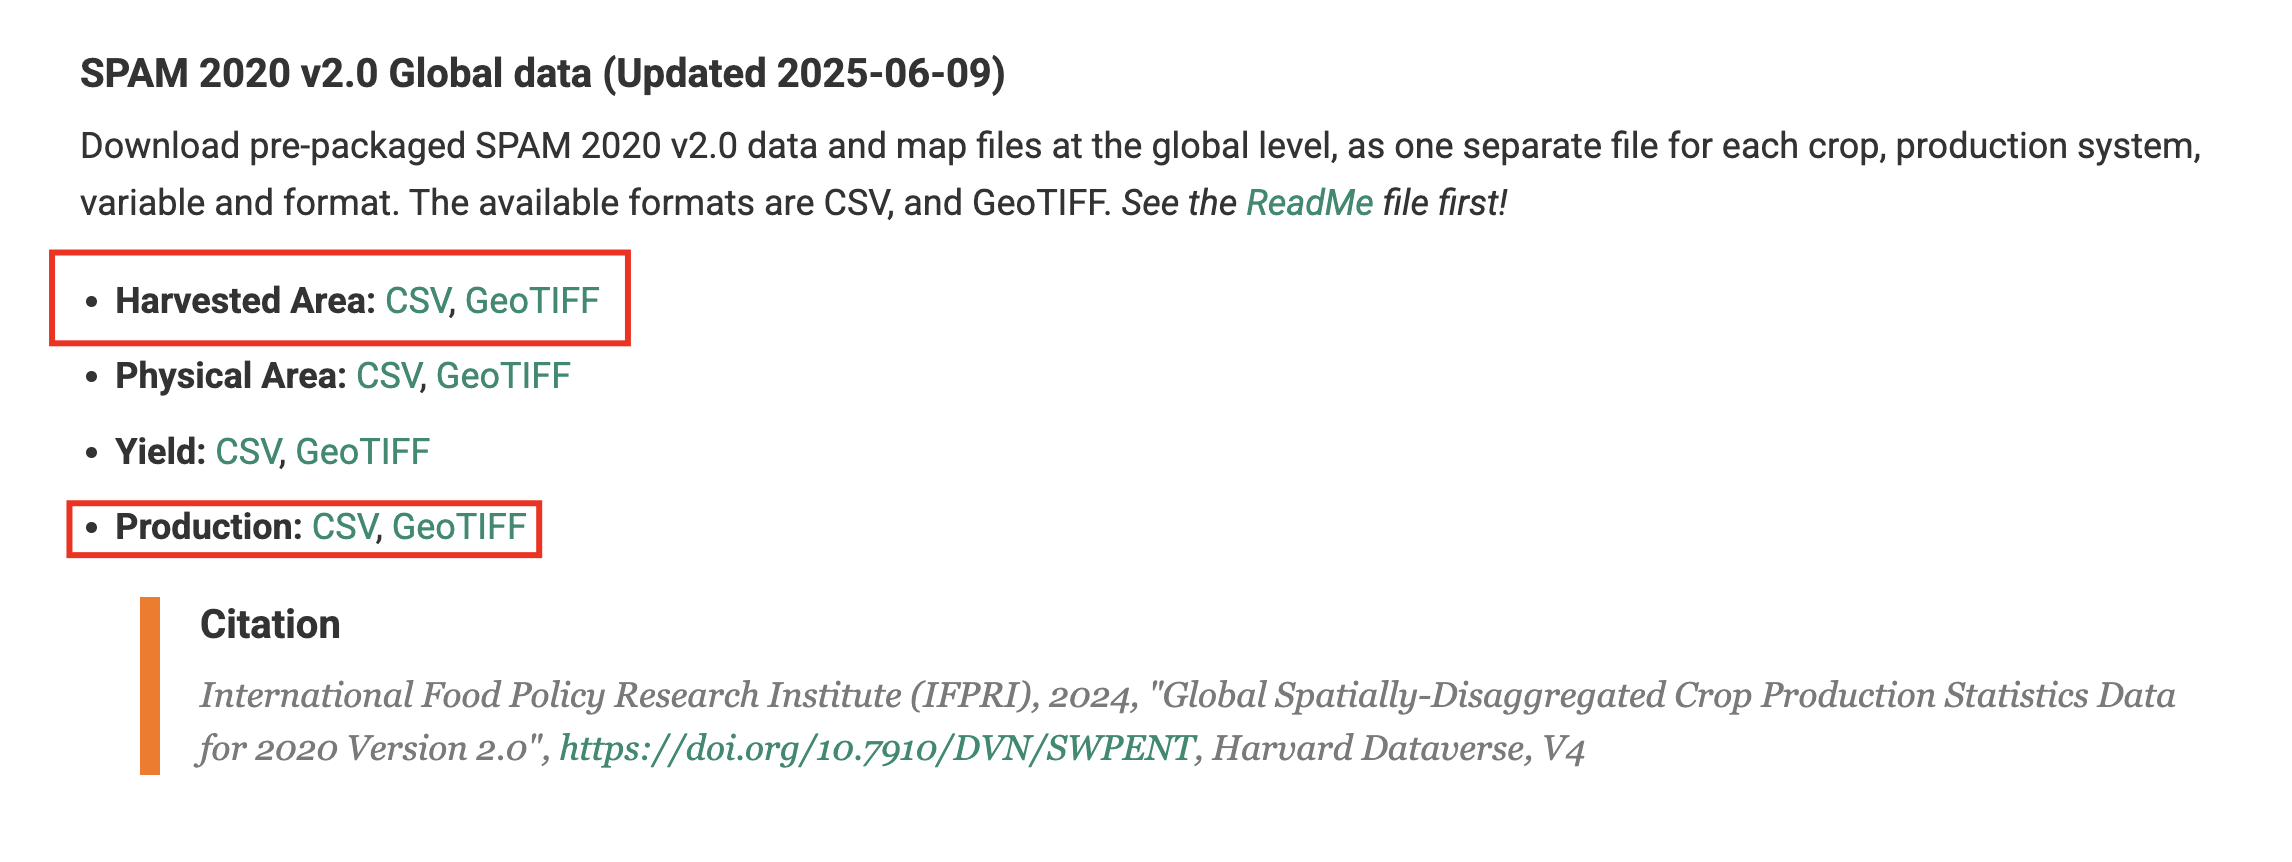

Make the Exposure

In [2]:
from utils_cb import get_crop_prod_exposure, COUNTRY_BOUNDS, FILES_CROP_PROD, FILES_CROP_HARVEST

# Get the exposure object for the given crop and bounding box based on the SPAM crop production data
exp = get_crop_prod_exposure(file = INPUT_DIR / FILES_CROP_PROD["coffee"], # file path to the crop production data
                                             bbox = COUNTRY_BOUNDS['MEX'], # bounding box for the country
                                            harvest_area_file= INPUT_DIR / FILES_CROP_HARVEST["coffee"] # file path to the harvest area data
                                            )

# Print the total production value
print(f"Total production value for coffee in Mexico: {exp.gdf['value'].sum()} tonnes")

# Lets rescale the production value given the total exported coffe from some source
total_exported_coffee = 167000  # Example value in tonnes
exp.gdf['value'] = exp.gdf['value'] * total_exported_coffee / exp.gdf['value'].sum()

Total production value for coffee in Mexico: 800116.625 tonnes


Look at the exposure data. 

As shown the majority of production is concentrated in southern Mexico—particularly.

In [3]:
from tabulate import tabulate

# Print and plot the exposure object
print(tabulate(exp.gdf.head(), headers='keys', tablefmt='psql'))

# Plot the exposure object
# exp.plot_basemap()

+----+----------+---------------------+------------------------------------------------+
|    |    value |   harvest_area (ha) | geometry                                       |
|----+----------+---------------------+------------------------------------------------|
|  0 | 0.020872 |                 1   | POINT (-100.9583333333513 23.87500000001502)   |
|  1 | 0.020872 |                 1   | POINT (-100.87500000001799 23.87500000001502)  |
|  2 | 0.020872 |                 1   | POINT (-100.79166666668468 23.87500000001502)  |
|  3 | 0.125232 |                 5.9 | POINT (-100.9583333333513 23.791666666681706)  |
|  4 | 0.020872 |                 1   | POINT (-100.70833333335136 23.791666666681706) |
+----+----------+---------------------+------------------------------------------------+


Add and replace the site coordinates provided by Christian Bunn

In [4]:
from pathlib import Path
from climada.entity import Exposures
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
from tabulate import tabulate

# Define input path
file = INPUT_DIR / "CoffeeCAM_anonymized.csv"

if file.exists():
    print(f"📄 File found: {file.name}")

    # Step 1: Load and convert CSV to GeoDataFrame
    df = pd.read_csv(file)
    # Only include the columns Longitude, Latitude
    df = df[['Longitude', 'Latitude']]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]), crs="EPSG:4326")
    gdf = gdf.drop(columns=["Longitude", "Latitude"])
    exp_sites = Exposures(gdf)

    # Step 2: Extract GeoDataFrames
    exp_gdf = exp.gdf.copy()
    new_sites_gdf = exp_sites.gdf.copy()

    # Step 3: Reproject to UTM for distance calculation
    orig_crs = exp_gdf.crs
    exp_gdf = exp_gdf.to_crs(epsg=32614)
    new_sites_gdf = new_sites_gdf.to_crs(exp_gdf.crs)

    # Step 4: Interpolate using inverse distance weighted NN
    tree = cKDTree(np.array([(pt.x, pt.y) for pt in exp_gdf.geometry]))
    tolerance = 2000  # meters
    new_values, new_areas = [], []

    for site_geom in new_sites_gdf.geometry:
        site_coord = np.array([site_geom.x, site_geom.y])
        idxs = tree.query_ball_point(site_coord, r=tolerance)

        if not idxs:
            new_values.append(np.nan)
            new_areas.append(np.nan)
            continue

        neighbors = exp_gdf.iloc[idxs]
        distances = np.array([site_geom.distance(pt) for pt in neighbors.geometry])
        distances[distances == 0] = 1e-6
        weights = 1 / distances
        weights /= weights.sum()

        new_values.append(np.sum(weights * neighbors["value"].values))
        new_areas.append(np.sum(weights * neighbors["harvest_area (ha)"].values))

    new_sites_gdf["value"] = new_values
    new_sites_gdf["harvest_area (ha)"] = new_areas
    new_sites_gdf = new_sites_gdf.dropna(subset=["value", "harvest_area (ha)"])
    new_sites_gdf = new_sites_gdf.to_crs(orig_crs)

    # Step 5: Replace exposure object
    exp_interpolated = Exposures(new_sites_gdf)
    exp_interpolated.value_unit = exp.value_unit
    exp = exp_interpolated  # 👈 replace original exposure

    # Step 6: Display results
    print("✅ Exposure object successfully updated from CoffeeCAM_anonymized.csv")
    print(tabulate(exp.gdf.head(), headers="keys", tablefmt="psql"))
    #exp.plot_basemap()

else:
    print(f"⚠️ File not found: {file}")


📄 File found: CoffeeCAM_anonymized.csv
✅ Exposure object successfully updated from CoffeeCAM_anonymized.csv
+-----+---------+---------------------+-----------------------------------------+
|     |   value |   harvest_area (ha) | geometry                                |
|-----+---------+---------------------+-----------------------------------------|
|  78 | 14.4643 |               955.8 | POINT (-99.04789627 21.47238839)        |
|  82 | 14.4643 |               955.8 | POINT (-99.03123769 21.458290509999998) |
|  84 | 14.4643 |               955.8 | POINT (-99.03515156 21.449611379999997) |
|  85 | 14.4643 |               955.8 | POINT (-99.05082035 21.44880705)        |
| 104 | 77.435  |              1714.6 | POINT (-98.94269195 21.38326803)        |
+-----+---------+---------------------+-----------------------------------------+


### 🌳 Canopy Cover Data

We use global forest canopy cover data from the University of Maryland's **Global Forest Change v1.7** dataset.

- Resolution: **30 m**
- Year: **2000 baseline**
- Source: [Hansen et al., Science 2013](https://earthenginepartners.appspot.com/science-2013-global-forest/download_v1.7.html)

This dataset is used to estimate **canopy cover** at each site when not provided in the exposure file.

*Later on it would be better to have the canopy composition data as a separate file.*

Download the data

In [8]:
from utils_cb import download_if_missing, generate_hansen_tile_urls_from_bounds

# Download Hansen tiles based for Mexico
tile_urls = generate_hansen_tile_urls_from_bounds(
    lat_min=10,
    lat_max=30,
    lon_min=-110,
    lon_max=-90
)    

# Download each tile
dest_folder =  INPUT_DIR / "Hansen_TreeCover"
for fname, url in tile_urls.items():
    print(fname, "→", url)
    download_if_missing(url, dest_folder =  INPUT_DIR / "Hansen_TreeCover"
, filename=fname)

Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif
Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif
Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif
Hansen_GFC-2019-v1.7_treecover2000_20N_110W.tif → https://storage.goog

Load the data

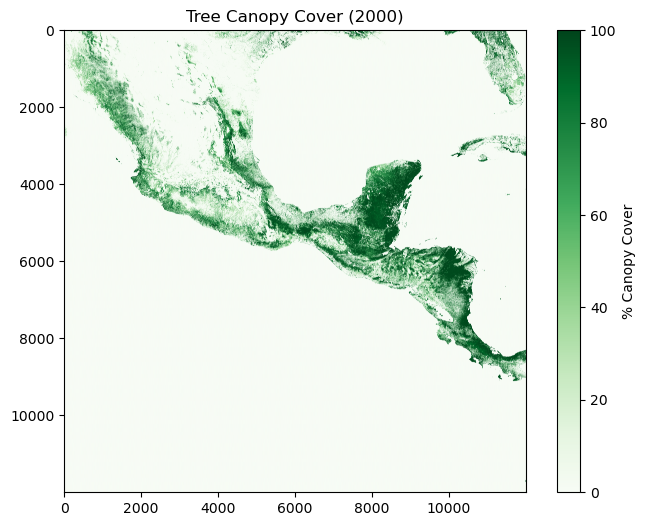

In [9]:
from utils_cb import merge_rasters, downsample_raster, add_canopy_cover_to_exposure
import matplotlib.pyplot as plt

# --- CONFIG ---
canopy_tif_path = INPUT_DIR / "merged_treecover2000.tif" # Path to the canopy raster file

# Load the merged raster file
if not canopy_tif_path.exists():
    print("Merged file not found. Creating...")
    merge_rasters(input_dir = INPUT_DIR / "Hansen_TreeCover", # input directory containing the raster tiles
                 output_path = canopy_tif_path # output path for the merged raster
                    )

# Plot
downsampling_factor = 10  # or None for full resolution for faster plotting
plt.figure(figsize=(8, 6))
plt.imshow(downsample_raster(canopy_tif_path, downsampling_factor), 
           cmap='Greens')
plt.colorbar(label='% Canopy Cover')
title = f"Tree Canopy Cover (2000)"
plt.title(title)
plt.show()

To estimate the canopy cover to each site, we add the average canopy cover by creating a buffer zone aorund the grid-point/site.

In [10]:
# Add canopy cover to the exposure object
buffer_m = 500  # Buffer in meters for the exposure points
exp = add_canopy_cover_to_exposure(exp, canopy_tif_path, buffer_m)
print(tabulate(exp.gdf[["value", "canopy_cover", "harvest_area (ha)"]].head(), headers='keys', tablefmt='psql'))

+-----+---------+----------------+---------------------+
|     |   value |   canopy_cover |   harvest_area (ha) |
|-----+---------+----------------+---------------------|
|  78 | 14.4643 |        87.1594 |               955.8 |
|  82 | 14.4643 |        87.9772 |               955.8 |
|  84 | 14.4643 |        83.0158 |               955.8 |
|  85 | 14.4643 |        80.2184 |               955.8 |
| 104 | 77.435  |        86.6992 |              1714.6 |
+-----+---------+----------------+---------------------+


## 3 – Hazard 

**Data Sources – Terra climate**

https://www.climatologylab.org/terraclimate.html

🌡️ VPD – Vapour Pressure Deficit

We model Vapour Pressure Deficit (VPD) as a key climate hazard, similar to the paper Kath et al. (2022), Nature Food. The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts for coffee.

We calculate the mean VPD over the crop-specific growing season: Mexico: June to December



Download the data 

In [11]:
from utils_cb import download_terraclimate_data

# Download historical TerraClimate data for Mexico
download_terraclimate_data(
    output_dir = INPUT_DIR / "terra_climate",
    country_code="MEX",
    lat_bounds=(32, 13),
    lon_bounds=(-120, -85),
    variables=["tmax", "vpd"], # Variables to download
    years=range(1985, 2023),
    download_type="historical"
)


# Download future scenario data for +2C
download_terraclimate_data(
    output_dir = INPUT_DIR / "terra_climate",
    download_type="scenario",
    scenario="plus2C",
    scenario_prefix="2c",
    country_code="MEX",
    lat_bounds=(32, 13),
    lon_bounds=(-120, -85),
    variables=["tmax", "vpd"],  # Variables to download
    years=range(1985, 2015)
)

✅ Skipping existing: TerraClimate_tmax_1985_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1986_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1987_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1988_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1989_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1990_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1991_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1992_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1993_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1994_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1995_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1996_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1997_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1998_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1999_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2000_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2001_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2002_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2003_MEX.nc
✅ Skipping existing: TerraClima

Load the raster files to generate present and future hazard

📂 Loading 38 files for variable 'vpd'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
📂 Loading 30 files for variable 'vpd'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...


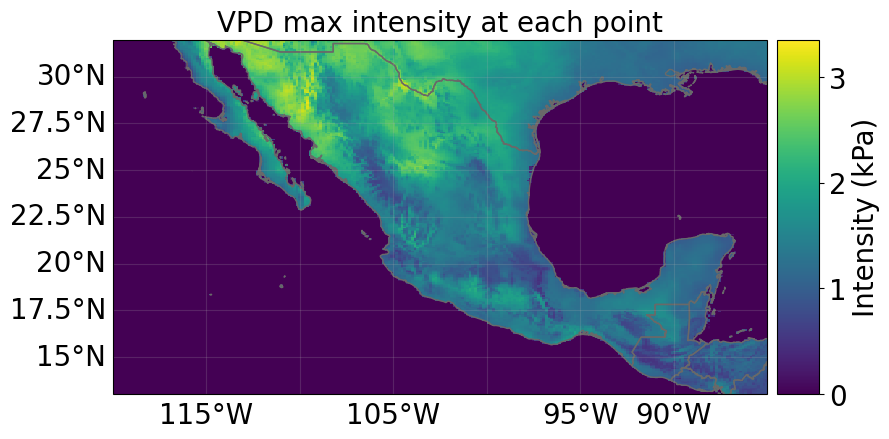

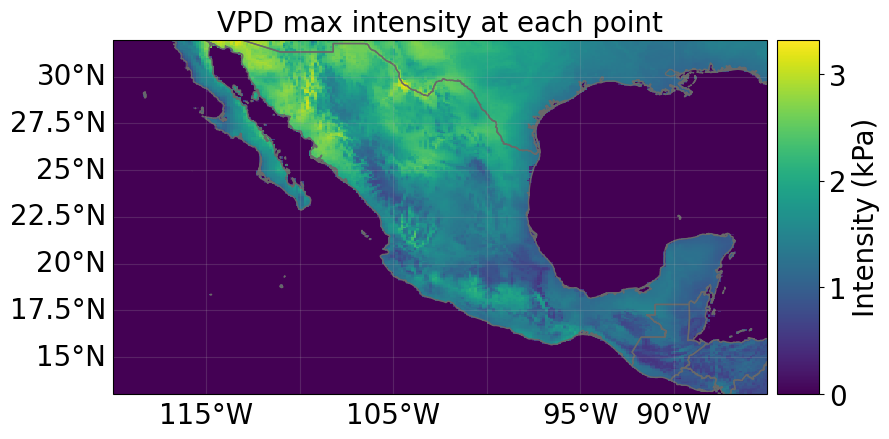

In [12]:
from utils_cb import create_hazard_from_nc_files
from climada.hazard import Hazard

# Determine the corresponding parameters for the hazard type
nc_files = {'present': [], 'future': []}
haz_dict = {'present': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg = 'mean',
    varname = 'vpd'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_MEX.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus2C_vpd_*_MEX.nc"))
    units = 'kPa'
    months = [5, 6, 7, 8, 9, 10, 11]  # April to November
elif hazard_type == 'Tmax':
    agg = 'max'
    varname = 'tmax'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_MEX.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus2C_tmax_*_MEX.nc"))
    units = 'C'
    months = [5, 6, 7, 8, 9, 10, 11] # April to November


# Store the hazard type and parameters in a dictionary
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
                        nc_files[key],
                        varname=varname,
                        haz_type=hazard_type,
                        units=units,
                        agg=agg[0],
                        months=months,
                        nan_replacement=0.0  # Use NaN to keep sparse matrix
                    )
    # Plot the hazard object
    haz_dict[key].plot_intensity(0)


## Hazard intensity given the canopy level

Since the adaption measure is the change the canopy level at each site in relation to the curret levels. Each site may already be exposed to a different hazard inte


This Reproject the hazard values on the exposure sites and derive a different hazard set given the canopy level.. We do this because the hazard intenity will later on depend on the canopy level at each given site and some sites corresponds to the smae centroid in the hazard file.

Reproject the hazard values on the exposure sites. 

🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for present:
🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for future:


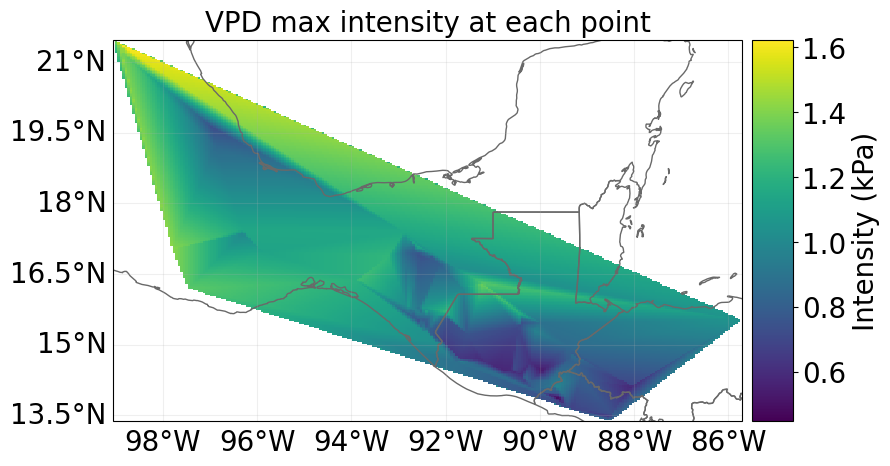

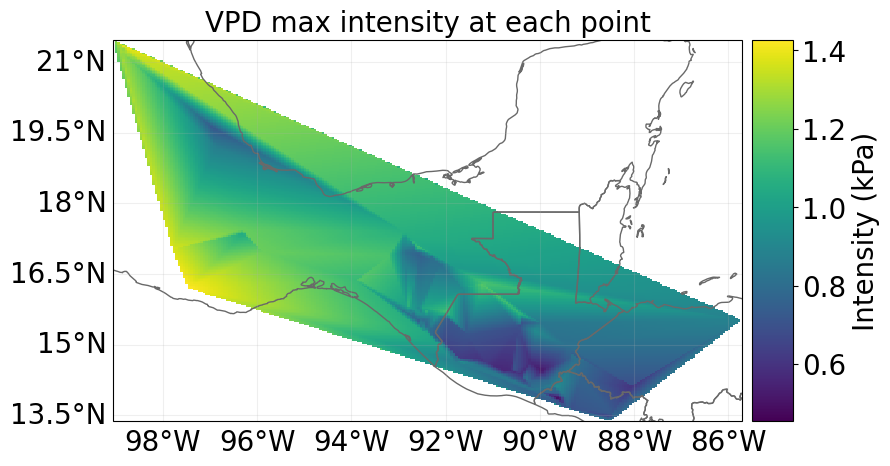

In [13]:
from utils_cb import reproject_hazard_to_exposures

haz_site_dict = {'present': Hazard, 'future': Hazard}

for key in haz_dict:
    # Reproject the hazard to the exposure sites
    haz_site_dict[key] = reproject_hazard_to_exposures(haz_dict[key], exp)
    # Plot the site-level hazard
    print(f"Site-level hazard for {key}:")
    haz_site_dict[key].plot_intensity(0)


We now make use of the `adjust_hazard_with_exposure_modifier` Define function in tersm of how much the canopy level changes the hazard

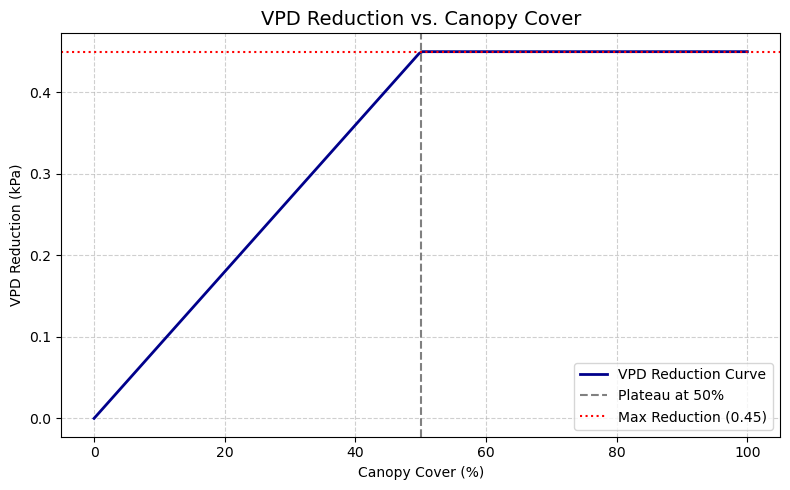

In [14]:
from utils_cb import helper_adj_fcn_canopy_tmax, helper_adj_fcn_canopy_vpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Decide the adjustment function and its parameters
if hazard_type.upper() == 'TMAX':
    adjustment_fn = helper_adj_fcn_canopy_tmax
    adjustment_kwargs = {
        "max_cooling": 2.5,
        "plateau_at": 50
    }
    ylabel = "Temperature Reduction (°C)"
    title = "Tmax Cooling Effect vs. Canopy Cover"
    label = "Cooling Curve"
elif hazard_type.upper() == 'VPD':
    adjustment_fn = helper_adj_fcn_canopy_vpd
    adjustment_kwargs = {
        "max_cooling": 3.0,
        "plateau_at": 50,
        "vpd_sensitivity": 0.15
    }
    ylabel = "VPD Reduction (kPa)"
    title = "VPD Reduction vs. Canopy Cover"
    label = "VPD Reduction Curve"
else:
    raise ValueError(f"Unsupported hazard type: {hazard_type}")


# Inputs
canopy = np.linspace(0, 100, 200)
n_sites = len(canopy)

# Apply adjustment function
reduction = adjustment_fn(
    hazard_matrix=np.zeros((1, n_sites)),  # Dummy input,
    exposure_gdf=pd.DataFrame({'canopy_cover': canopy}),
    **adjustment_kwargs
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, reduction, label=label, linewidth=2, color="darkblue")
plt.axvline(adjustment_kwargs["plateau_at"], color='gray', linestyle='--', label=f'Plateau at {adjustment_kwargs["plateau_at"]}%')
plt.axhline(reduction.max(), color='red', linestyle=':', label=f'Max Reduction ({reduction.max():.2f})')

plt.title(title, fontsize=14)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


This function will be used to change the hazard intensity given the canopy level

<GeoAxes: title={'center': 'VPD max intensity at each point'}>

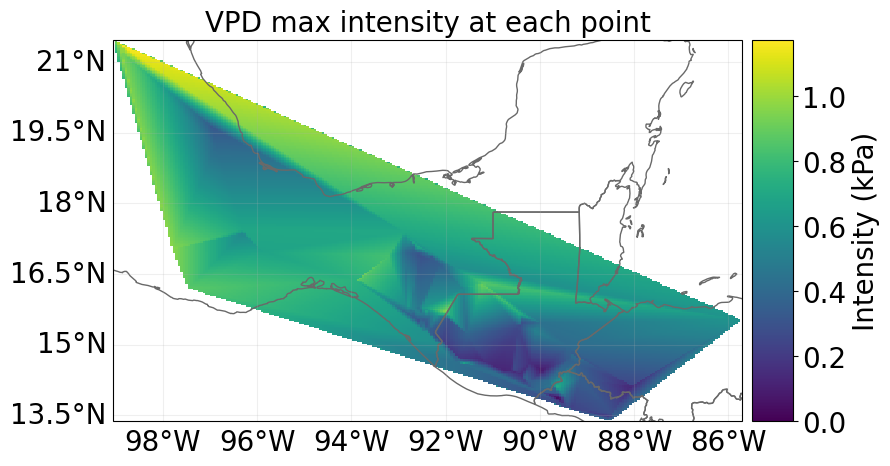

In [15]:
from utils_cb import apply_canopy_scenario, adjust_hazard_with_exposure_modifier

# Apply the adjustment function to the hazard object
exp_col = apply_canopy_scenario(exp, canopy_scenario="current") # or use a specific canopy cover value, e.g. 50
haz_site_adjusted = adjust_hazard_with_exposure_modifier(
    exposure=exp_col,
    hazard = haz_site_dict['present'],
    adjustment_fn = adjustment_fn,
    adjustment_kwargs=adjustment_kwargs
)

# Plot intensity of first event/year
haz_site_adjusted.plot_intensity(0)

The important part is later on to decide what we use a baseline hazard (incl. current canopy levels or not)  which will be used later on.

## 4 – Impact function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8)


<Axes: title={'center': 'VPD 1: VPD Empirical Yield Loss'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

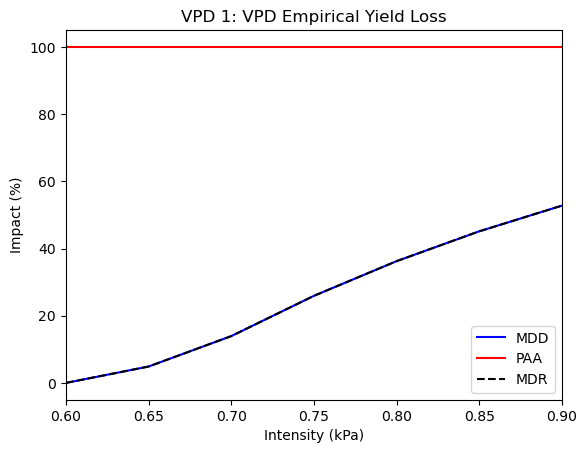

In [16]:
from utils_cb import impact_func_from_kath

hazard_type = 'VPD'

if hazard_type.upper() == 'TMAX':
    impf = impact_func_from_kath(
        file_path= "tasmax_effect_approximation.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="Tmax",
        unit="°C",
        name="Tmax Empirical Yield Loss"
    )
elif hazard_type.upper() == 'VPD':
    impf = impact_func_from_kath(
        file_path= "vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="VPD",
        unit="kPa",
        name="VPD Empirical Yield Loss"
    )

impf.plot()

Create an impact function set and define the id for the exposure

In [17]:
# Store the impact function in impact function set
from climada.entity import ImpactFuncSet

# Set the impact function for the hazard type
exp.gdf[f'impf_{hazard_type}'] = 1

# Create an ImpactFuncSet with the VPD impact function
imp_fun_set = ImpactFuncSet([impf])

## 6 – Impact Analysis including Uncertainty parameters

Note: This is a first attempt to comp


- Estimate key metrics: **AAI** and **Return Period Losses** under different canopy scenarios
- Use CLIMADA’s `UNSEQUA` module to include uncertainty in the analysis
- Current uncertainty parameters:
  - **Crop production** (Exposure)
  - **Impact function**
- Compare risk under two scenarios:
  - Current canopy levels
  - An increased minimum canopy scenario (all sites meet a defined baseline)
- Hazard uncertainty is **not** yet included (hazard is manually adjusted gven canopy levels and slow uncertainty computation)
- Planned extensions: include uncertainty in **canopy cover** and **cooling benefit**


Define the uncertainty variable

In [18]:
import copy
import scipy as sp
from functools import partial

from climada.engine.unsequa import InputVar

## Define the uncertainty variables for the exposure, impact function set, and hazard
# Exposure
exp_distr = {
    "e_value": sp.stats.uniform(0.5, 1.0), # Uniform distribution between 0.5 and 1.5 multiply with the crop productivity value
}

# Impact function set
impf_distr = {
    "i_seed": sp.stats.randint(low=1, high=1000), # Uniform distribution between 1 and 100 determines the random seed for the impact function
}


Define the uncertainty functions

In [19]:
## Define the uncertainty functions for the exposure, impact function set and hazard
from climada.entity import ImpactFuncSet
from utils_cb import generate_random_impact_func_from_ci

# Define the base exposure
def exp_func(e_value, exp_base=exp):
    # Copy the base exposure
    exp = copy.deepcopy(exp_base)
    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value
    return exp

# Impact function set
# Define the base impact function set
def impf_set_fun (i_seed):
    # Generate a random impact function from the VPD empirical yield loss
    return ImpactFuncSet([
        generate_random_impact_func_from_ci(  # helper function to generate a random impact function based on the confidence intervals of the paper 
            seed=int(i_seed),
            file_path='vpd_effect_approximation.csv' if hazard_type.upper() == 'VPD' else 'tasmax_effect_approximation.csv',
            name='Random VPD IF'
        )
    ])

Often, we want to look at the **relative impact** compared to the **total production**. To do this, we scale the exposure values so they sum to one. This allows us to calculate the **relative contribution** of each site to the total, and then estimate the **relative impact** accordingly.


In [20]:
# Make a scaled version of the exposure function to get a normalized exposure
def exp_scaled_func(*args, **kwargs):
    exp = exp_func(*args, **kwargs)
    exp.gdf["value"] = exp.gdf["value"] / exp.gdf["value"].sum()
    return exp

Define the input uncertainty variables

In [21]:
# Uncertainty variable dicts
exp_ivs = {
    "unscaled": InputVar(exp_func, exp_distr),
    "scaled": InputVar(exp_scaled_func, exp_distr)
}

impf_iv = InputVar(impf_set_fun, impf_distr)

# Outputs split by exposure type and hazard key
output_imp = {
    "unscaled": {},
    "scaled": {}
}


To assess the benefit of more shade, we create a **Minimum Canopy Scenario**:

- If a site's canopy is **below** the threshold, we raise it to the minimum.
- If it's **above**, we leave it unchanged.
- The updated canopy is used to recalculate hazard intensity (e.g. VPD).

This gives us an alternative hazard set to compare risk metrics (e.g. AAI) under improved conditions.


In [22]:
from utils_cb import compute_vpd_hazard

# Define the minimum canopy cover
min_canopy_cover = ['current', 30]  # Minimum canopy cover percentage
climate_scenario = 'future' # Climate scenario to use for the hazard computation

# Compute the hazard for each canopy scenario and climate scenario
haz_dict = {}  # Dictionary to store the hazard objects for each canopy scenario and climate scenario
for min_cov in min_canopy_cover:
    # Define the canopy cooling function
    exp_cool = apply_canopy_scenario(exp, canopy_scenario=min_cov)  # Apply the canopy scenario to the exposure
    # Name the measure 
    measure_name = f"Canopy Cover {min_cov}%"
    # Compute VPD hazard with canopy cooling
    haz_dict[measure_name] = adjust_hazard_with_exposure_modifier(
                            exposure=exp_cool,
                            hazard = haz_site_dict[climate_scenario], # hazard object for the climate scenario
                            adjustment_fn = adjustment_fn,
                            adjustment_kwargs=adjustment_kwargs
                            )



Derive the uncertainty metrics

In [23]:
from climada.engine.unsequa import CalcImpact

# Calculate the uncertainty and sensitivity for each hazard type and exposure mode
output_imp = {
    "unscaled": {},
    "scaled": {}
}

# Remove the sclaed and unscaled and include in the plot function instead
for key, haz in haz_dict.items():
    for mode in ["unscaled", "scaled"]:
        print(f"Calculating impact for {key} in {mode} mode...")
        exp_iv = exp_ivs[mode]
        calc_imp = CalcImpact(exp_iv, impf_iv, haz)
        samples = calc_imp.make_sample(N=2**7, sampling_kwargs={"skip_values": 2**8})
        result = calc_imp.uncertainty(samples, rp=list(range(1, 40)))
        result = calc_imp.sensitivity(result)
        output_imp[mode][key] = result


Calculating impact for Canopy Cover current% in unscaled mode...


/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np

Calculating impact for Canopy Cover current% in scaled mode...


/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np

Calculating impact for Canopy Cover 30% in unscaled mode...


/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np

Calculating impact for Canopy Cover 30% in scaled mode...


/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np

We now visualize the **distribution of impacts** under the current and minimum canopy scenarios.

To estimate the **economic value** of the impacts, we assume:
- The value of crop losses corresponds to the **first stage of the value chain** (e.g. farmgate price).
- Prices are based on **current futures market estimates** for each crop. https://markets.businessinsider.com/commodities/coffee-price

This allows us to interpret the distribution in both **biophysical (tonnes lost)** and **monetary terms (USD lost)**, enabling a more policy-relevant cost-benefit comparison.


Some helper functions to visulize the results

Total crop production: 9,878.38 tons
Average price per ton: 4,764.00 USD/ton
Total value of the exposure: 47,060,623.08 USD


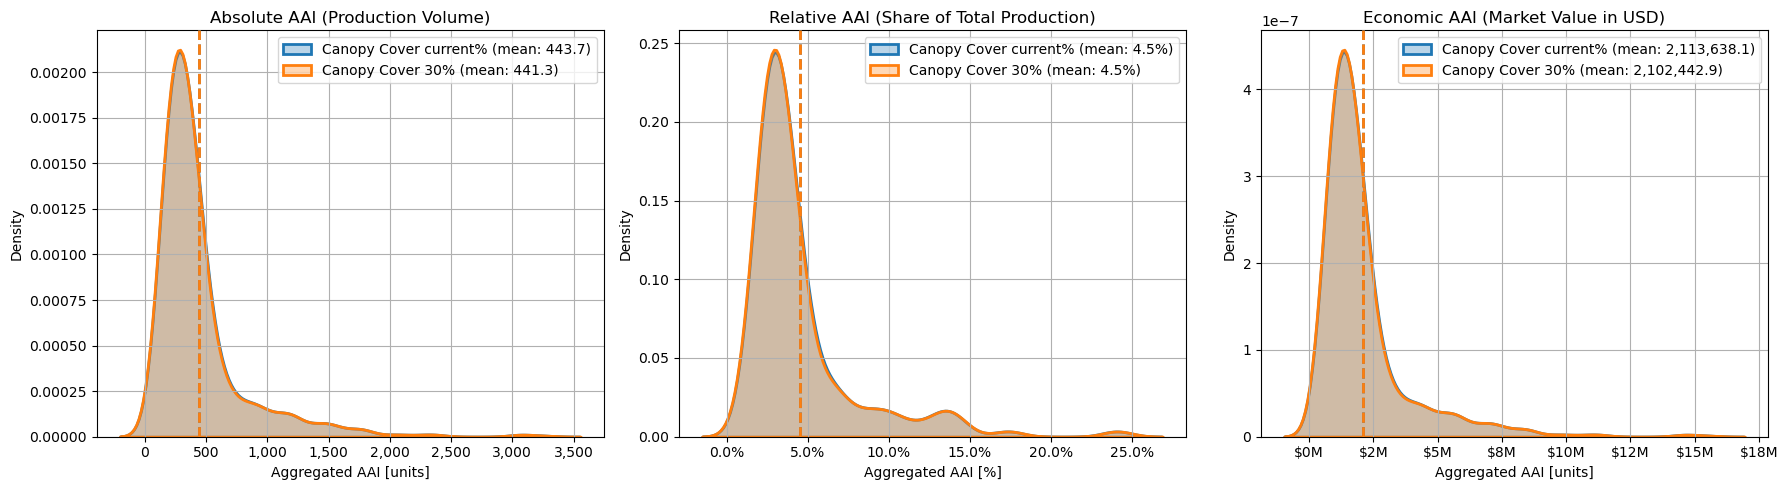

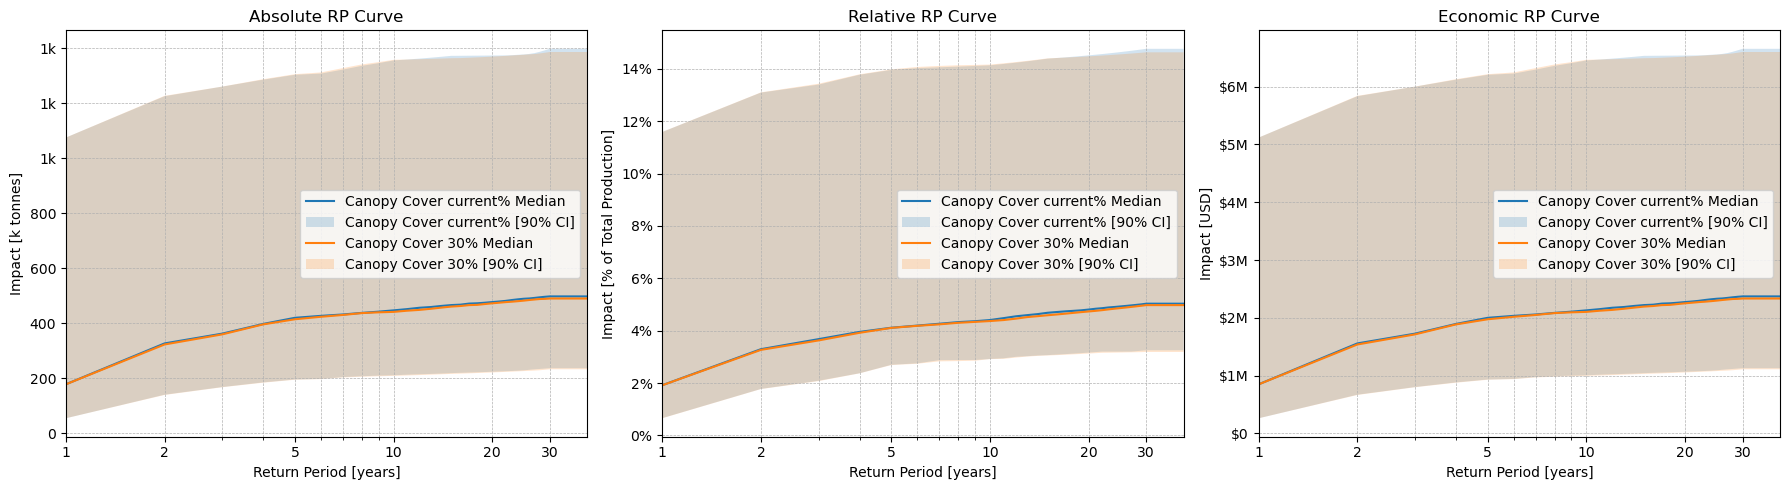

In [24]:
from utils_cb import plot_kde_and_rp_panels

price_per_ton = 7.94 *0.6*1000   # USD/tonne  # Price per ton of crop for the impact calculation

# USe a visual format for the output´
print(f"Total crop production: {exp.gdf['value'].sum():,.2f} tons")
print(f"Average price per ton: {price_per_ton:,.2f} USD/ton")
print(f"Total value of the exposure: {exp.gdf['value'].sum()*price_per_ton:,.2f} USD")

plot_kde_and_rp_panels(output_imp, price_per_ton)


### Sensitivity Analysis – What Drives the Variation?

To better understand what drives uncertainty in the impact estimates, we perform a **sensitivity analysis**.

This analysis helps identify which input parameters (e.g. exposure, impact function, hazard) contribute the most to the variation in results.  
By quantifying their influence, we can:

- Prioritize **which variables need better data** to reduce uncertainty,
- Guide **future data collection efforts**, and
- Improve model confidence and decision-making relevance.

For example:
- If **crop exposure** (production values) explains most of the variation, then better spatial yield data is needed.
- If the **impact function** is highly sensitive, we may need more locally calibrated vulnerability curves.


Plotting sensitivity for Canopy Cover current%...
Plotting sensitivity for Canopy Cover 30%...


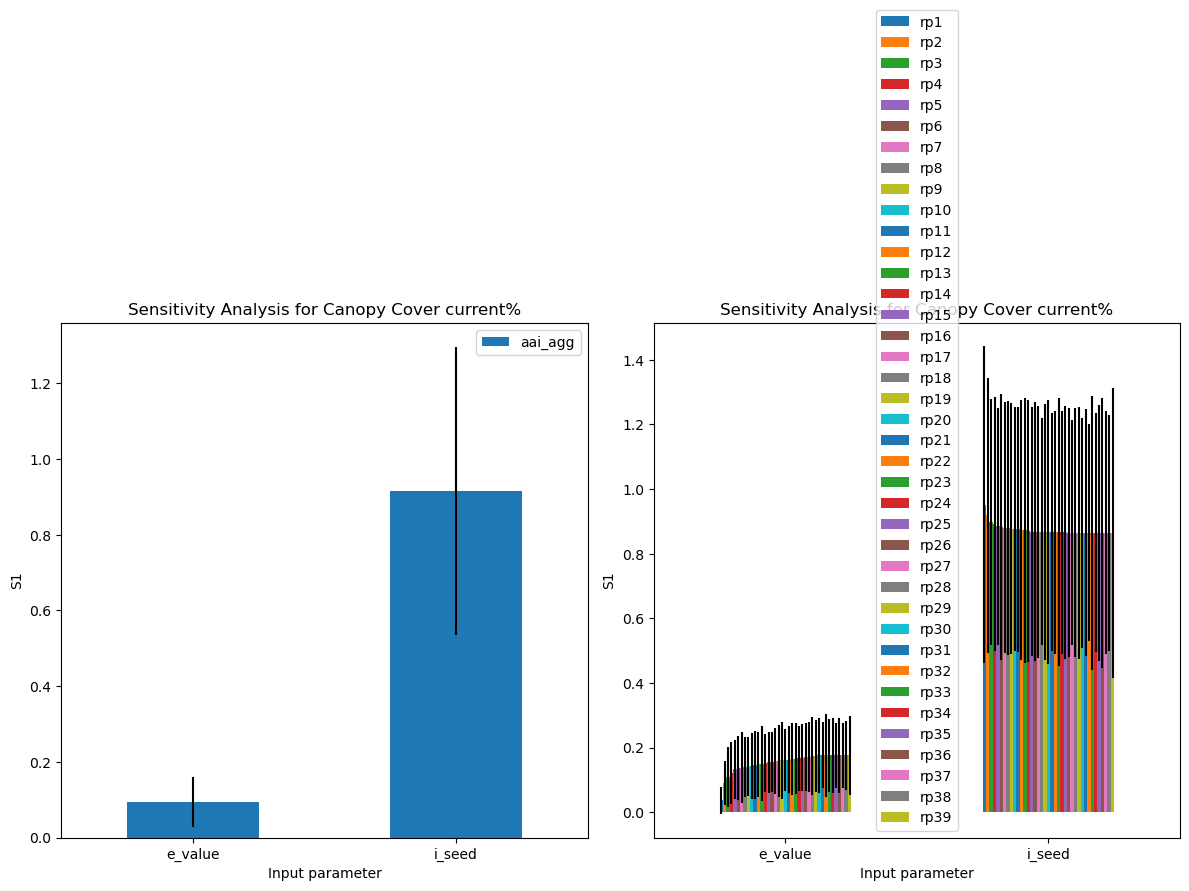

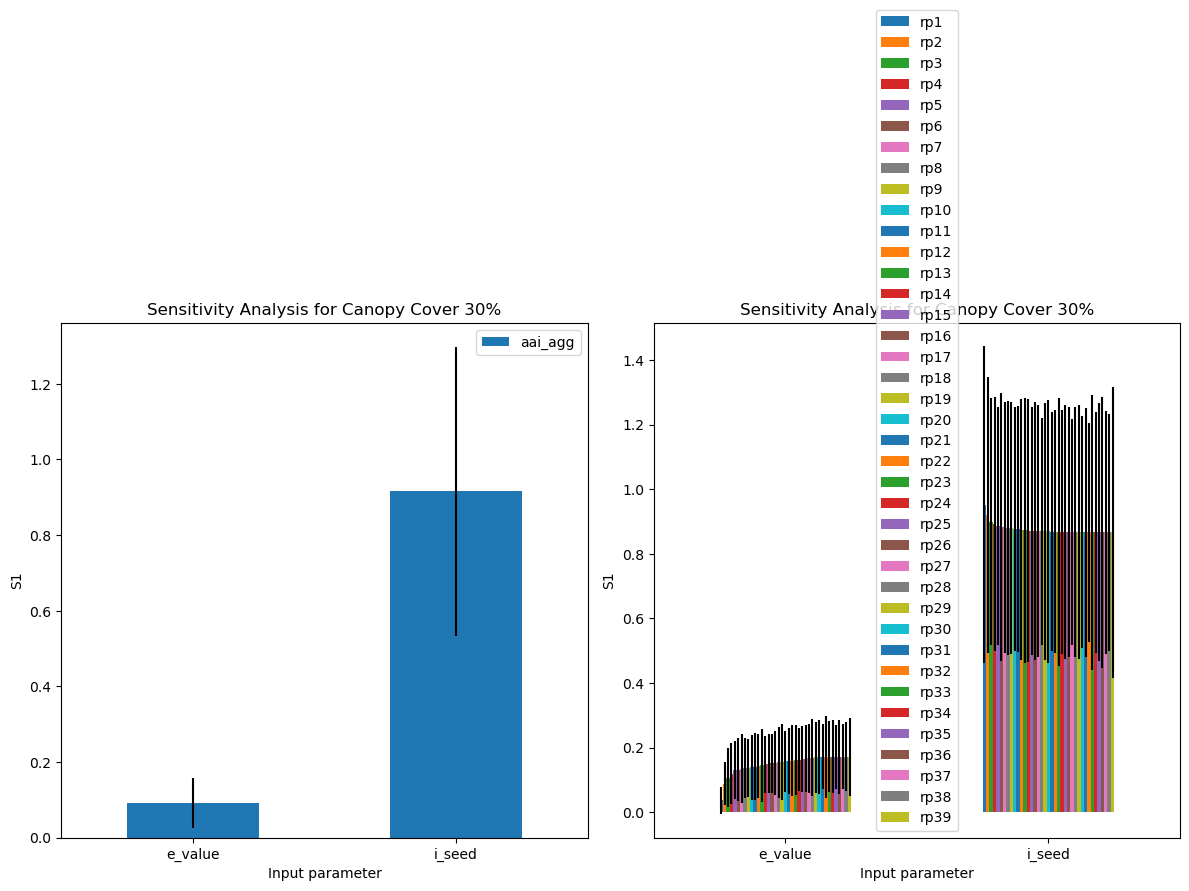

In [25]:
for key in output_imp["unscaled"].keys():
    print(f"Plotting sensitivity for {key}...")
    output_imp["unscaled"][key].plot_sensitivity(figsize=(12, 8), title=f"Sensitivity Analysis for {key}")

## 6 – Define the Adaptation Measures 

Here we define the measures. 
In this set up we only compare measures of different shade levels.  

In [26]:
# Define the minimum canopy cover
min_canopy = [30, 60]  # Minimum canopy cover percentage
n_years = 10 # Number of years for the investment horizon

# Define shared canopy cost parameters
canopy_cost_params = {
    "setup_cost_per_ha": 300, # Setup cost per hectare for the canopy cover investment $200–600 (trees, planting, fencing)
    "annual_maint_cost_per_ha": 30, # Annual maintenance cost per hectare for the canopy cover investment $20–50
    "duration_years": n_years,  # Duration of the investment in years
    "discount_rate": 0.02,  # Discount rate for the investment
}

Define the measures

In [27]:
from climada.entity.measures import Measure, MeasureSet
from utils_cb import compute_additional_canopy_cost

# Create a meaure set to store the measures
meas_set = MeasureSet()

# For each canopy cover percentage, define the measure by computing the hazard and cost
for canopy in min_canopy:
    # Apply the canopy scenario to the exposure
    exp_cool = apply_canopy_scenario(exp, canopy_scenario=canopy)  # Apply the canopy scenario to the exposure
    # Compute the hazard using the exposure object and canopy level
    haz_meas = adjust_hazard_with_exposure_modifier(
                        exposure=exp_cool,
                        hazard = haz_site_dict[climate_scenario], # hazard object for the climate scenario
                        adjustment_fn = adjustment_fn,
                        adjustment_kwargs=adjustment_kwargs
                        )
    # Save the hazard to the output directory
    haz_file = OUTPUT_DIR / f"haz_{canopy}.h5"
    haz_meas.write_hdf5(haz_file)
    print(f"Stored hazard {canopy} in {OUTPUT_DIR / f'haz_{canopy}.h5'}")
    
    # Define the measure
    meas =  Measure(
        name= f"Canopy Cover {canopy}%", # Name of the measure
        haz_type = hazard_type,
        # Give the measure a random color
        color_rgb = np.random.rand(3,),
        cost = compute_additional_canopy_cost(exp, min_canopy_percent=canopy, **canopy_cost_params)[0],
        hazard_set = haz_file  # Path to the hazard file
    )
    
    # Append the measure to the measure set
    meas_set.append(meas)
    meas_set.check()

Stored hazard 30 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_30.h5
Stored hazard 60 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_60.h5


## 7 - Cost Benefit with uncertainties

Uncertainty parameters
- Cost (Measure)
- Current crop production (Entity - Present)
- Growth of future crops production (Entity - Future)

Define the discount rate

Read file: /Users/viggo/climada/data/entity_template.xlsx


<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

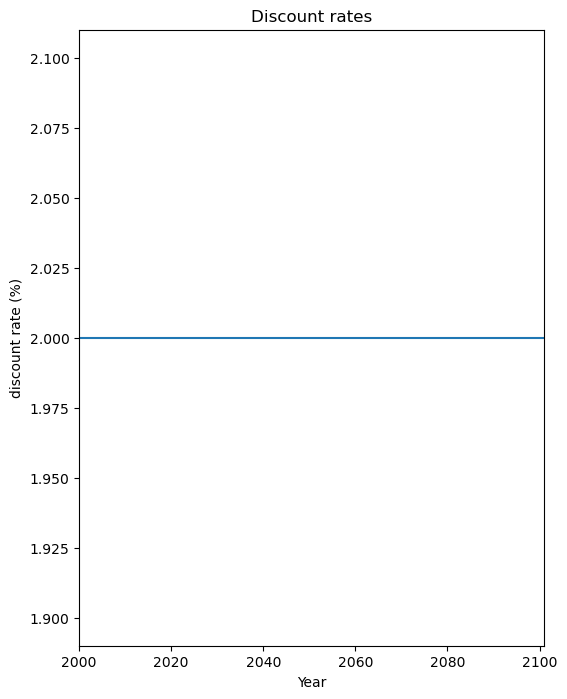

In [28]:
from climada.entity import DiscRates
from climada.util import ENT_TEMPLATE_XLS

# Fill DataFrame from Excel file
file_name = ENT_TEMPLATE_XLS  # provide absolute path of the excel file
print("Read file:", ENT_TEMPLATE_XLS)
disc = DiscRates.from_excel(file_name)
disc.plot()

Define the uncertainty variables

In [29]:
ent_today_distr = {"e_value": sp.stats.uniform(0.8, 1.2), # Crop productivity value distribution ranging from 0.8 to 1.2
                   "m_cost": sp.stats.uniform(0.8, 1.2) # Maintenance cost distribution ranging from 0.8 to 1.2
                   }

ent_future_distr = {"e_growth": sp.stats.uniform(0.8, 1.2) # Crop productivity growth distribution ranging from 0.8 to 1.2
                     }

Define the uncertainty variable functions

In [30]:
import copy
from climada.entity import Entity

exp_monetary = copy.deepcopy(exp)  # Create a monetary copy of the exposure object
exp_monetary.gdf["value"] *= price_per_ton  # Scale the exposure value by the price per ton
exp_monetary.value_unit = "USD"  # Set the value unit to USD
exp_monetary.ref_year = 2023
exp_fut_base = copy.deepcopy(exp_monetary)  # Create a base copy of the exposure object for the future entity
exp_fut_base.ref_year += n_years  # Set the reference year for the future exposure

# Entity today has an uncertainty in the total asset value
def ent_today_func(e_value, m_cost, # The uncertainty parameters
                   exp_base=exp_monetary, impf_func_base=imp_fun_set, measure_set_base=meas_set, disc_base=disc # The base objects to copy and modify
                   ):
    # Copy the base objects
    exp = copy.deepcopy(exp_base)
    impf_func_set = copy.deepcopy(impf_func_base)
    meas_set = copy.deepcopy(measure_set_base)
    disc_rate = copy.deepcopy(disc_base)


    # Scale the value of the exposure by the e_value and price per ton
    exp.gdf["value"] *= e_value

    # Scale the cost of the measure by the m_cost
    for meas in measure_set_base.get_measure(hazard_type):
        meas.cost *= m_cost

    # Create the entity
    return Entity(  exposures=exp,
                    impact_func_set=impf_func_set,
                    measure_set=meas_set,
                    disc_rates= disc_rate
                )

# Entity future has an uncertainty in the growth of the asset value
def ent_future_func(
    e_growth,  # Uncertainty parameter: asset value growth factor
    exp_fut_base=exp_fut_base,
    impf_func_base= imp_fun_set,
    measure_set_base=meas_set,
    disc_base=disc
):
    # Copy base inputs
    exp = copy.deepcopy(exp_fut_base)
    impf_func_set = copy.deepcopy(impf_func_base)
    meas_set = copy.deepcopy(measure_set_base)
    disc_rate = copy.deepcopy(disc_base)

    # Scale exposure value based on growth factor
    exp.gdf["value"] *= e_growth

    # Create and return future entity
    return Entity(
        exposures=exp,
        impact_func_set=impf_func_set,
        measure_set=meas_set,
        disc_rates=disc_rate
    )


Make the baseline hazard - correspondning to "No Measure" in the cost benefit assement.

In [31]:
haz_baseline_dict = {'present': Hazard, 'future': Hazard}

for climate_scenario in ['present', 'future']:
    # Apply the canopy scenario to the exposure
    exp_cool = apply_canopy_scenario(exp, canopy_scenario='current')  # Use the first canopy cover percentage for the baseline
    # Compute VPD hazard with canopy cooling
    haz_baseline_dict[climate_scenario] = adjust_hazard_with_exposure_modifier(
                                exposure=exp_cool,
                                hazard = haz_site_dict[climate_scenario], # hazard object for the climate scenario
                                adjustment_fn = adjustment_fn,
                                adjustment_kwargs=adjustment_kwargs
                                )

Define  the  uncertainty variables

In [32]:
import scipy as sp
from climada.engine.unsequa import InputVar
from climada.engine.unsequa import CalcCostBenefit


unc_cb = CalcCostBenefit(
    haz_input_var= haz_baseline_dict[climate_scenario],  # Use the adjusted hazard for the present
    ent_input_var=InputVar(ent_today_func, ent_today_distr),
    haz_fut_input_var = None,  # No future hazard input variable needs to be updated
    ent_fut_input_var = InputVar(ent_future_func, ent_future_distr)
    )


In [33]:
output_cb = unc_cb.make_sample(N=10^2, sampling_kwargs={"calc_second_order": False})
output_cb.get_samples_df().tail()

,e_value,m_cost,e_growth
35,1.0625,1.8125,0.9125
36,1.4375,1.8125,0.9125
37,1.0625,1.2875,0.9125
38,1.0625,1.8125,1.5125
39,1.4375,1.2875,1.5125


Calculate the uncertainty metrics

In [34]:
# without pool
output_cb = unc_cb.uncertainty(output_cb)


Measure             Cost (USD k)    Benefit (USD k)    Benefit/Cost
----------------  --------------  -----------------  --------------
Canopy Cover 30%         49.9994            77.9062        1.55814
Canopy Cover 60%       2400.38             745.083         0.310402

--------------------  --------  -------
Total climate risk:   10726.2   (USD k)
Average annual risk:   1297.19  (USD k)
Residual risk:         9903.26  (USD k)
--------------------  --------  -------
Net Present Values

Measure             Cost (USD k)    Benefit (USD k)    Benefit/Cost
----------------  --------------  -----------------  --------------
Canopy Cover 30%         68.1242            77.9062        1.14359
Canopy Cover 60%       3270.52             745.083         0.227818

--------------------  --------  -------
Total climate risk:   10726.2   (USD k)
Average annual risk:   1297.19  (USD k)
Residual risk:         9903.26  (USD k)
--------------------  --------  -------
Net Present Values

Measure        

Make distirbution plots of Total risk & benefit, cost, benfit/cost, 

Metric              Scenario                    Mean    5th Percentile    95th Percentile
------------------  ----------------  --------------  ----------------  -----------------
AAI (Present)       No measure            1340030.26         865188.28         1868425.86
AAI (Future)        No measure            1368592.19         868758.52         1868425.86
AAI (Present)       Canopy Cover 30%      1330297.44         858904.30         1854855.23
AAI (Future)        Canopy Cover 30%      1358651.92         862448.61         1854855.23
AAI (Present)       Canopy Cover 60%      1246946.98         805089.21         1738638.33
AAI (Future)        Canopy Cover 60%      1273524.89         808411.45         1738638.33
Total Climate Risk  All                  13513885.27        9413468.68        16428681.22
Cost (NPV)          Canopy Cover 30%    914152450.81         104943.76      5386618512.50
Benefit (NPV)       Canopy Cover 30%        98153.16          68371.29          119323.71
Cost-Benef

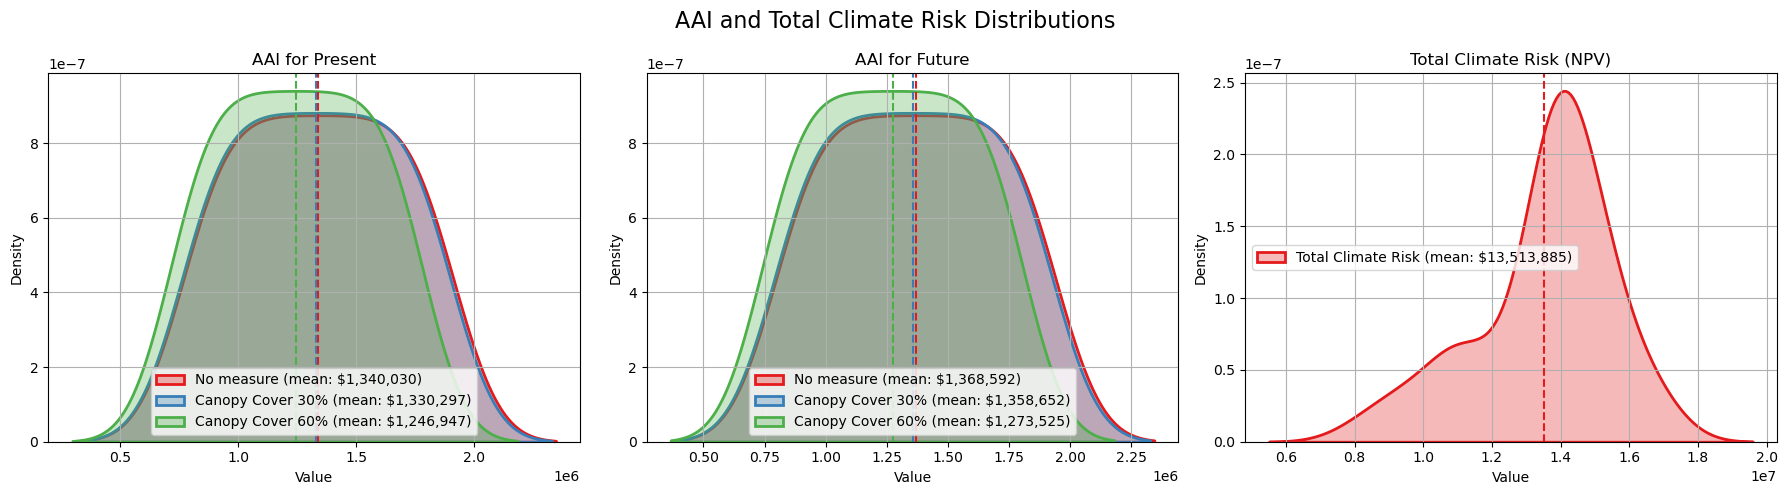

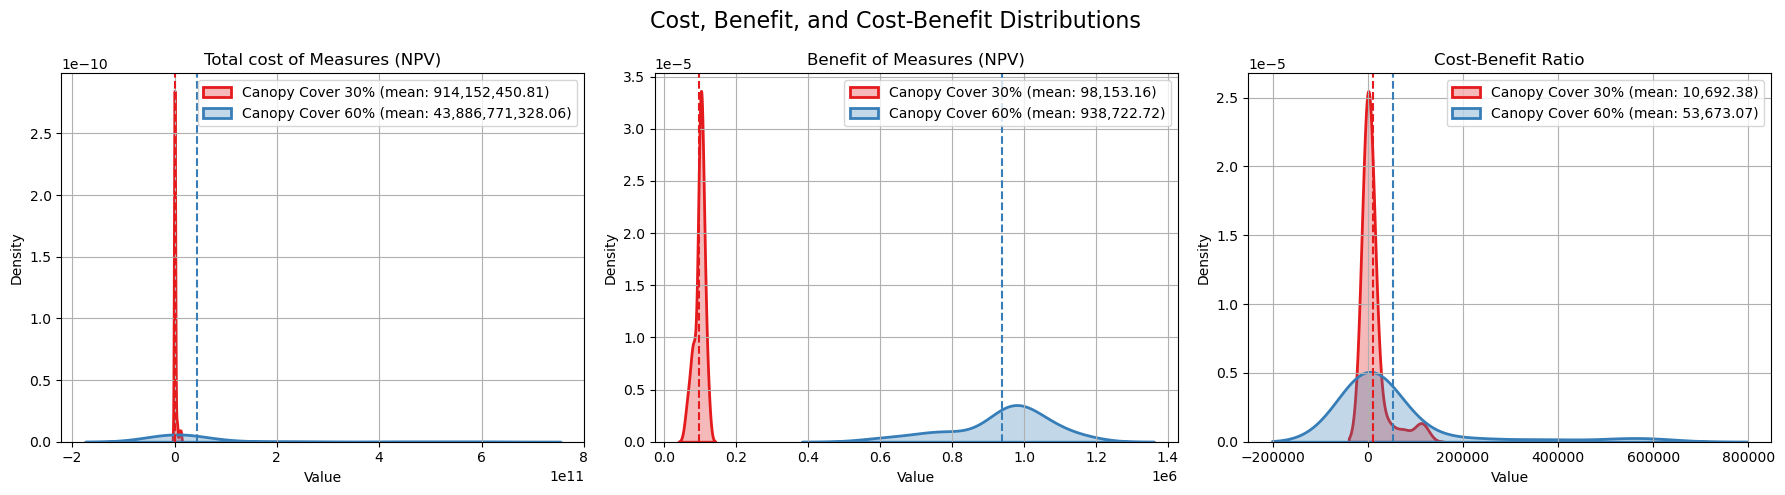

In [35]:
from utils_cb import print_summary_statistics, plot_kde_panel
from collections import OrderedDict

# Print summary statistics for the output DataFrame
measure_names = meas_set.get_names(hazard_type)
print_summary_statistics(output_cb.get_uncertainty(), measure_names)

# Define the columns to plot for each subplot
column_map = OrderedDict({
    "AAI for Present": [("No measure", "no measure - risk - present")] + [(meas, f"{meas} - risk - present") for meas in measure_names],
    "AAI for Future":  [("No measure", "no measure - risk - future")]  + [(meas, f"{meas} - risk - future") for meas in measure_names],
    "Total Climate Risk (NPV)": [("Total Climate Risk", "tot_climate_risk")]
})

plot_kde_panel(output_cb.get_uncertainty(), column_map, suptitle="AAI and Total Climate Risk Distributions")

column_map_cb = OrderedDict({
    "Total cost of Measures (NPV)": [(meas, f"{meas} - cost_meas - future") for meas in measure_names],
    "Benefit of Measures (NPV)": [(meas, f"{meas} Benef") for meas in measure_names],
    "Cost-Benefit Ratio": [(meas, f"{meas} CostBen") for meas in measure_names],
})

plot_kde_panel(output_cb.get_uncertainty(), column_map_cb, suptitle="Cost, Benefit, and Cost-Benefit Distributions", value_format="{:,.2f}")